In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

In [13]:
df = pd.read_csv('student_data_cleaned.csv')
print(f"Loaded clean dataset: {df.shape[0]} rows, {df.shape[1]} columns.")

Loaded clean dataset: 6607 rows, 20 columns.


In [14]:
possible_files = [
    'student_data_cleaned.csv',
    'StudentPerformanceFactors.csv',
    'student_data.csv'
]

data_file = None
for f in possible_files:
    if os.path.exists(f):
        data_file = f
        break

if data_file is None:
    raise FileNotFoundError("Please upload 'student_data_cleaned.csv' or 'StudentPerformanceFactors.csv' via the left Files panel in Colab!")

print(f"Loading dataset from: {data_file}")
df = pd.read_csv(data_file)

Loading dataset from: student_data_cleaned.csv


In [15]:
if df['Teacher_Quality'].isnull().sum() > 0:
    df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])
if df['Parental_Education_Level'].isnull().sum() > 0:
    df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0])
if df['Distance_from_Home'].isnull().sum() > 0:
    df['Distance_from_Home'] = df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0])

df.loc[df['Exam_Score'] > 100, 'Exam_Score'] = 100

In [16]:
os.makedirs("visualizations", exist_ok=True)
print(f"Dataset successfully loaded: {df.shape[0]} rows, {df.shape[1]} columns.")

Dataset successfully loaded: 6607 rows, 20 columns.


Target Variable Distribution (Exam Score)

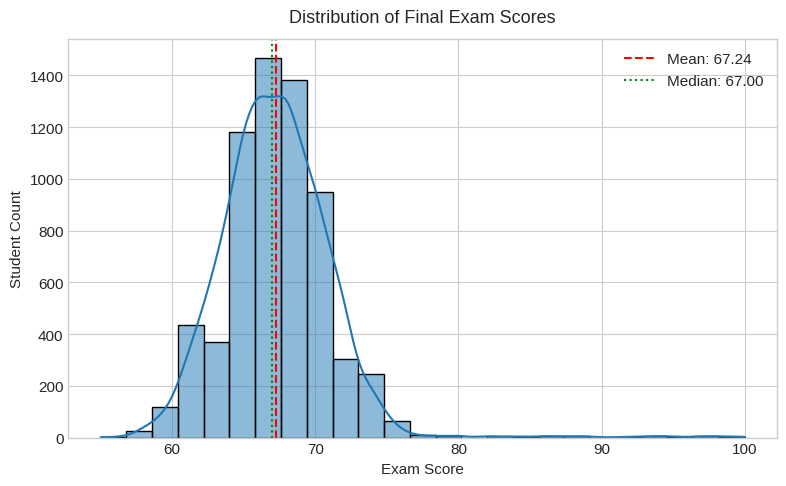

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Exam_Score'], kde=True, bins=25, color='#1f77b4', edgecolor='black')
plt.axvline(df['Exam_Score'].mean(), color='red', linestyle='--', label=f"Mean: {df['Exam_Score'].mean():.2f}")
plt.axvline(df['Exam_Score'].median(), color='green', linestyle=':', label=f"Median: {df['Exam_Score'].median():.2f}")

plt.title('Distribution of Final Exam Scores', fontsize=13, pad=12)
plt.xlabel('Exam Score')
plt.ylabel('Student Count')
plt.legend()
plt.tight_layout()
plt.savefig("visualizations/01_exam_score_distribution.png", dpi=300)
plt.show()

Attendance vs Exam Score

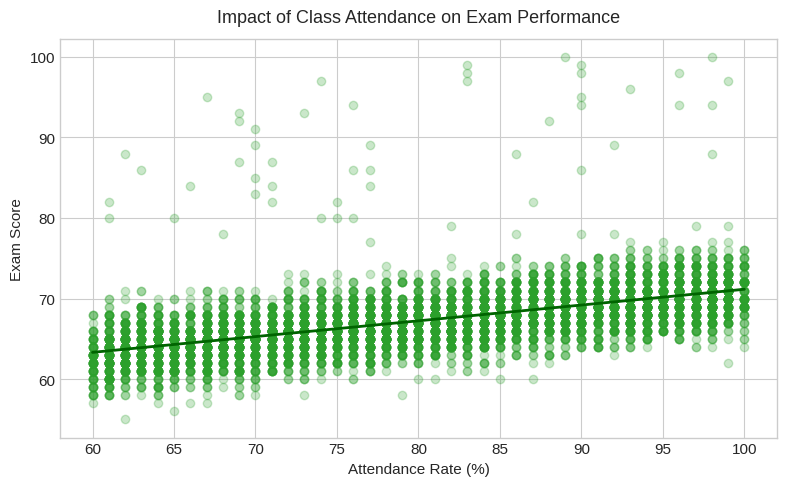

In [18]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df, x='Attendance', y='Exam_Score',
    scatter_kws={'alpha': 0.25, 'color': '#2ca02c'},
    line_kws={'color': 'darkgreen', 'linewidth': 2}
)

plt.title('Impact of Class Attendance on Exam Performance', fontsize=13, pad=12)
plt.xlabel('Attendance Rate (%)')
plt.ylabel('Exam Score')
plt.tight_layout()
plt.savefig("visualizations/02_attendance_vs_exam_score.png", dpi=300)
plt.show()

Hours Studied vs Exam Score

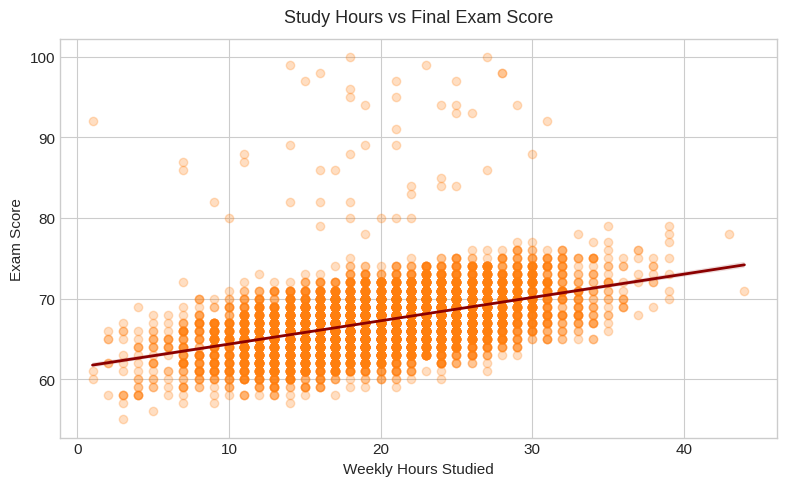

In [19]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df, x='Hours_Studied', y='Exam_Score',
    scatter_kws={'alpha': 0.25, 'color': '#ff7f0e'},
    line_kws={'color': 'darkred', 'linewidth': 2}
)

plt.title('Study Hours vs Final Exam Score', fontsize=13, pad=12)
plt.xlabel('Weekly Hours Studied')
plt.ylabel('Exam Score')
plt.tight_layout()
plt.savefig("visualizations/03_hours_studied_vs_exam_score.png", dpi=300)
plt.show()

Previous Scores vs Exam Score

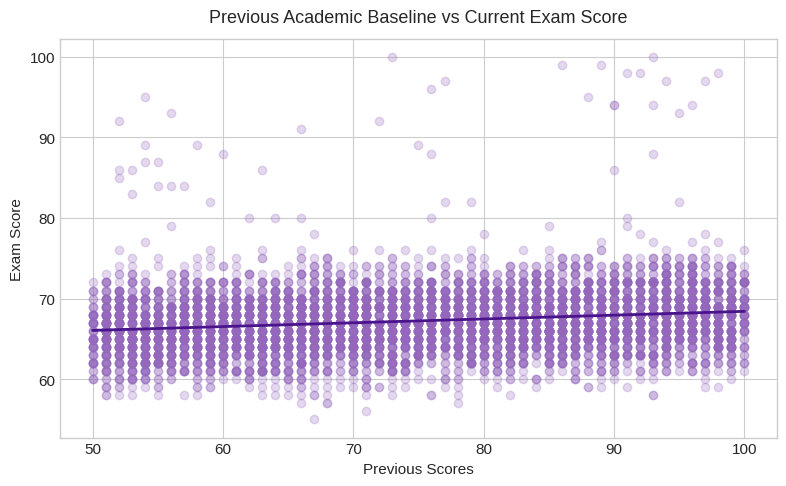

In [20]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df, x='Previous_Scores', y='Exam_Score',
    scatter_kws={'alpha': 0.25, 'color': '#9467bd'},
    line_kws={'color': '#4a148c', 'linewidth': 2}
)

plt.title('Previous Academic Baseline vs Current Exam Score', fontsize=13, pad=12)
plt.xlabel('Previous Scores')
plt.ylabel('Exam Score')
plt.tight_layout()
plt.savefig("visualizations/04_previous_scores_vs_exam_score.png", dpi=300)
plt.show()

Environmental & Behavioral Factors (Boxplots)

/tmp/ipykernel_2550/709315208.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='Parental_Involvement', y='Exam_Score', order=order_pi, palette='Blues')
/tmp/ipykernel_2550/709315208.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df, x='Access_to_Resources', y='Exam_Score', order=order_ar, palette='Oranges')


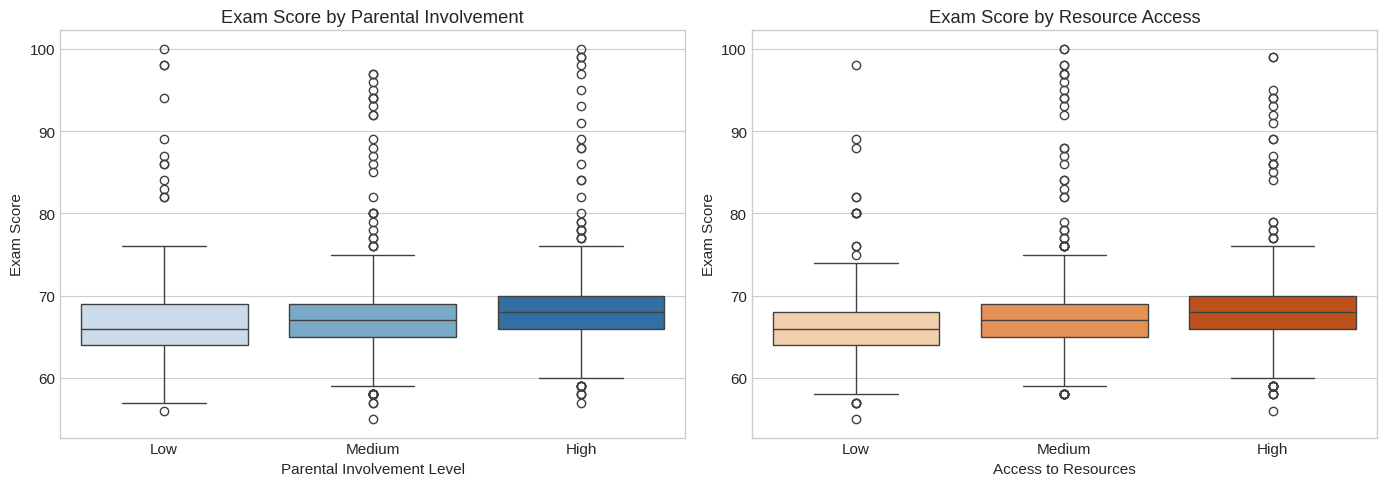

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_pi = ['Low', 'Medium', 'High']
sns.boxplot(ax=axes[0], data=df, x='Parental_Involvement', y='Exam_Score', order=order_pi, palette='Blues')
axes[0].set_title('Exam Score by Parental Involvement')
axes[0].set_xlabel('Parental Involvement Level')
axes[0].set_ylabel('Exam Score')

order_ar = ['Low', 'Medium', 'High']
sns.boxplot(ax=axes[1], data=df, x='Access_to_Resources', y='Exam_Score', order=order_ar, palette='Oranges')
axes[1].set_title('Exam Score by Resource Access')
axes[1].set_xlabel('Access to Resources')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.savefig("visualizations/05_environmental_factors_boxplot.png", dpi=300)
plt.show()